<a href="https://colab.research.google.com/github/howonJeong/Journey_to_TinyLLAMA/blob/main/Step1_MitDeep/1.6.3_TwoLayerNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..'))
import numpy as np

In [ ]:
def softmax(x):
    if x.ndim == 2:
        x = x.T
        x = x - np.max(x, axis=0)
        y = np.exp(x) / np.sum(np.exp(x), axis=0)
        return y.T

    x = x - np.max(x) # 오버플로 대책
    return np.exp(x) / np.sum(np.exp(x))

def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 훈련 데이터가 원-핫 벡터라면 정답 레이블의 인덱스로 반환
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

def numerical_gradient(f, x):
    h = 1e-4 # 0.0001
    grad = np.zeros_like(x)

    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]
        x[idx] = float(tmp_val) + h
        fxh1 = f(x) # f(x+h)

        x[idx] = tmp_val - h
        fxh2 = f(x) # f(x-h)
        grad[idx] = (fxh1 - fxh2) / (2*h)

        x[idx] = tmp_val # 값 복원
        it.iternext()

    return grad

sigmoid = lambda x : 1 / (1 + np.exp(-x))

In [ ]:
class simpleNet:
  def __init__(self):
    self.W = np.random.randn(4,4)
    #정규분포 랜덤 가중치로 스타토

  def predict(self, x):
    return np.dot(x, self.W)

  def loss(self, x, t):
    z = self.predict(x)
    y = softmax(z)
    loss = cross_entropy_error(y, t)

    return loss

In [ ]:
net = simpleNet()
print(net.W)

[[-1.98745397  0.30349388  2.18453479  0.25453693]
 [ 0.39189352  0.37469109  0.80719011 -1.7873126 ]
 [ 1.72029958 -0.63883147 -0.65765402  0.67947313]
 [-0.3535939   0.28546821 -1.8653872  -0.79636753]]


In [ ]:
x = np.array([0.6, 0.9, 0.1, 0.1])
p = net.predict(x) #앞에 넷
print(p)

[-0.70309765  0.48398199  1.78488785 -1.46754863]


In [ ]:
np.argmax(p)
#최댓값의 인덱스

np.int64(2)

In [ ]:
t = np.array([0,0,1,0]) #정답 레이블 / 인덱스
net.loss(x, t)

np.float64(0.3322073270939623)

In [ ]:
def f(W):
  return net.loss(x, t)

dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.03575666  0.1171923  -0.16959689  0.01664792]
 [ 0.05363499  0.17578845 -0.25439533  0.02497189]
 [ 0.00595944  0.01953205 -0.02826615  0.00277465]
 [ 0.00595944  0.01953205 -0.02826615  0.00277465]]


In [ ]:
f = lambda w: net.loss(x,t)

In [ ]:
print(numerical_gradient(f, net.W))
#람다 써도 되고..

[[ 0.03575666  0.1171923  -0.16959689  0.01664792]
 [ 0.05363499  0.17578845 -0.25439533  0.02497189]
 [ 0.00595944  0.01953205 -0.02826615  0.00277465]
 [ 0.00595944  0.01953205 -0.02826615  0.00277465]]


In [ ]:
class TwoLayerNet:
  def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
    self.params = {}
    self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
    self.params['b1'] = np.zeros(hidden_size) #사이즈 집중
    self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
    self.params['b2'] = np.zeros(output_size)

  def predict(self, x):
    W1, W2 = self.params['W1'], self.params['W2']
    b1, b2 = self.params['b1'], self.params['b2']

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    y = softmax(a2)

    return y

  def loss(self, x, t):
    y = self.predict(x)

    return cross_entropy_error(y, t)

  def accuracy(self, x, t):
    y = self.predict(x)
    y = np.argmax(y, axis = 1)
    t = np.argmax(t, axis = 1)

    accuracy = np.sum(y==t) / float(x.shape[0]) #왜 x.shape[0]
    return accuracy

  def numerical_gradeint(self, x, t):
    loss_W = lambda W: self.loss(x,t)

    grads = {}
    grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
    grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
    grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
    grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

    return grads

In [ ]:
!git clone https://github.com/WegraLee/deep-learning-from-scratch.git

sys.path.append('/content/deep-learning-from-scratch')

from dataset.mnist import load_mnist
from ch05.two_layer_net import TwoLayerNet

fatal: destination path 'deep-learning-from-scratch' already exists and is not an empty directory.


In [ ]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

# 확인
print(x_train.shape) # (60000, 784)
print(t_train.shape) # (60000, 10)

Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!
(60000, 784)
(60000, 10)


In [ ]:
#이제부터는 평가! (학습 코드에서 변수 몇개 추가 선언 + 마지막 부분이 학습 파트)

In [ ]:
train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

iters_num = 10000
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

network = TwoLayerNet(input_size=28*28, hidden_size=50, output_size=10)

for i in range(iters_num):
  batch_mask = np.random.choice(train_size, batch_size)
  x_batch = x_train[batch_mask]
  t_batch = t_train[batch_mask]

  grad = network.gradient(x_batch, t_batch)

  for key in ('W1', 'b1', 'W2', 'b2'):
    network.params[key] -= learning_rate * grad[key]

  loss = network.loss(x_batch, t_batch)
  train_loss_list.append(loss)

  #평가 데이터는 훈련 데이터와 처음부터 분리된 상태로 받으므로 accuracy만 따져주면 된다
  if i % iter_per_epoch == 0:
    train_acc = network.accuracy(x_train, t_train)
    test_acc = network.accuracy(x_test, t_test)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

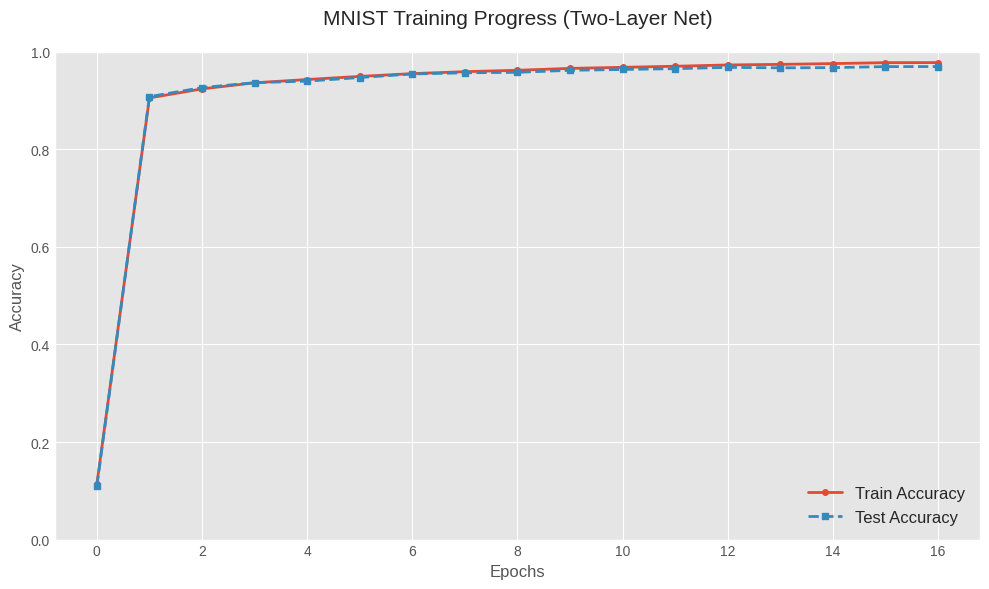

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.style.use('ggplot')

epochs = np.arange(len(train_acc_list))
plt.plot(epochs, train_acc_list, label='Train Accuracy', marker='o', markersize=4, linewidth=2)
plt.plot(epochs, test_acc_list, label='Test Accuracy', linestyle='--', marker='s', markersize=4, linewidth=2)

plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("MNIST Training Progress (Two-Layer Net)", fontsize=15, pad=20)
plt.ylim(0, 1.0)
plt.legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

데이터셋 갯수 : 전체 손님

배치 사이즈 : 카트에 실어나를 음식 인분 수

배치(이터레이션) (per Epoch) : 그러면 카트 몇번 왕복?

에폭 : 전체 손님이 식사를 받은 상태를 1 에폭